# 04 - CNN severity (Phase B)

Goal: a small CNN on early-window raster crops, predicting the same binary
escalation target as the tabular EBM (`02_feature_engineering.ipynb` Step
9), as the comparator for the planned Grad-CAM vs. SHAP/EBM
interpretability comparison. Full architecture/curation reasoning lives in
`docs/cnn_plan.md`; this notebook builds the crop store, sanity-checks it,
and reports the CNN's LOYO results (Step 5) against the frozen tabular
baseline (Step 4).

This session stops after Step 5 (CNN LOYO results) -- Grad-CAM and
ablations are a follow-up pass on top of these numbers.

Runs in the `flashpoint_mps` kernel (native arm64, torch 2.3.1 + MPS) --
NOT `flashpoint` (x86_64/Rosetta, no working torch). See README "Setup"
and CLAUDE.md for why there are two environments. Per CLAUDE.md,
`flashpoint_mps` is deliberately lean (no xgboost/interpret-core/shap):
tabular comparison numbers are read from `02_feature_engineering.ipynb`'s
committed results (README "Plan"), not recomputed here.

Everything here reads pixels ONLY from
`read_event_window(event, BUFFER_DAYS, BUFFER_DAYS + CUTOFF_DAY)` -- the
same leakage-respecting window `features.py` uses. Reaching past that
window would leak the label, since severity/escalation is derived from
the full trajectory.

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path

DB_PATH = Path("../data/flashpoint.duckdb")
CROP_STORE_PATH = Path("~/ml_datasets/flashpoint/early_crops_144.h5").expanduser()

CUTOFF_DAY = 2    # fire's first 2 actual days -- matches notebook 02's CUTOFF_DAY
CROP_SIZE = 128   # model input / eval crop size (48km at 375m/px)
STORE_SIZE = 144  # stored crop size -- leaves +/-JITTER_PX margin for train-time jitter
JITTER_PX = 8
SEEDS = (0, 1, 2)

## Step 0: environment verification

Phase 0 fixed the x86_64 `flashpoint` env's broken torch/numpy ABI by moving CNN work to `flashpoint_mps` entirely -- fail loudly here rather than discover it mid-training.

In [2]:
import numpy as np
import torch

torch_ver = tuple(int(x) for x in torch.__version__.split("+")[0].split(".")[:2])
assert torch_ver >= (2, 3), (
    f"torch {torch.__version__} < 2.3 -- breaks under numpy 2.x ABI, see docs/cnn_plan.md Phase 0"
)
assert torch.backends.mps.is_available(), "MPS not available -- check this is the flashpoint_mps kernel"

_ = torch.from_numpy(np.zeros(3, dtype=np.float32))  # raised "Numpy is not available" pre-Phase-0

print(f"python {sys.version.split()[0]}")
print(f"torch {torch.__version__}, MPS available: {torch.backends.mps.is_available()}")
print(f"numpy {np.__version__}")

python 3.11.15
torch 2.3.1, MPS available: True
numpy 2.0.1


## Step 1: load events/outcomes, derive escalates, eligibility filter

In [3]:
import duckdb
import pandas as pd

from flashpoint.data_access import BUFFER_DAYS

con = duckdb.connect(str(DB_PATH), read_only=True)
events_df = con.execute("SELECT * FROM events").df()
outcomes_df = con.execute("SELECT event_id, severity_class FROM event_outcomes").df()

df = events_df.merge(outcomes_df, on="event_id")
df["escalates"] = (df["severity_class"] > 0).astype(int)

min_days = BUFFER_DAYS + CUTOFF_DAY
eligible = df["n_days"] >= min_days
print(f"{(~eligible).sum()} events below {min_days} stored days "
      f"({BUFFER_DAYS} buffer + {CUTOFF_DAY} fire days) -- dropped")
df = df[eligible].reset_index(drop=True)

print(f"{len(df)} eligible events")
print(df["escalates"].value_counts().sort_index().rename("count"))

0 events below 6 stored days (4 buffer + 2 fire days) -- dropped
607 eligible events
escalates
0    155
1    452
Name: count, dtype: int64


## Step 2: build/load crop store

`rasters.build_crop_store` is the only place pixels get read for this
notebook, via `read_event_window(event, BUFFER_DAYS, BUFFER_DAYS +
CUTOFF_DAY)`. Store already exists from the Phase B build session (1.31GB,
built from all 607 events) -- this cell reuses it rather than rebuilding.
`n_edge_clipped` is reported at the 144px *store* size (the pre-jitter
margin); the smaller 128px eval crop clips less often -- verified
separately during `rasters.py` development at 69/607 (11.4%), matching
`docs/cnn_plan.md`'s figure exactly.

In [4]:
import h5py

from flashpoint.rasters import build_crop_store

if CROP_STORE_PATH.exists():
    print(f"using existing crop store at {CROP_STORE_PATH}")
else:
    stats = build_crop_store(df, CROP_STORE_PATH, store_size=STORE_SIZE, cutoff_day=CUTOFF_DAY)
    print(stats)

with h5py.File(CROP_STORE_PATH, "r") as f:
    crops = f["crops"][:]
    plane_names = [n.decode() if isinstance(n, bytes) else n for n in f.attrs["plane_names"]]
    event_ids = np.array([e.decode() for e in f["event_id"][:]])
    years = f["year"][:]
    n_fallback = int(f.attrs["n_fallback_center"])
    n_clipped = int(f.attrs["n_edge_clipped"])
    store_size = int(f.attrs["store_size"])
    cutoff_day_attr = int(f.attrs["cutoff_day"])

assert store_size == STORE_SIZE
assert cutoff_day_attr == CUTOFF_DAY
assert crops.shape == (len(df), len(plane_names), STORE_SIZE, STORE_SIZE)

# align df (and the labels/years derived from it) to the crop store's row order
df = df.set_index("event_id").loc[event_ids].reset_index()
assert (df["event_id"].to_numpy() == event_ids).all()
assert (df["year"].to_numpy() == years).all()
labels = df["escalates"].to_numpy()

print(f"\ncrops: {crops.shape}, {len(plane_names)} planes")
print(f"plane names: {plane_names}")
print(f"fallback center: {n_fallback}/{len(df)} ({n_fallback / len(df):.1%})")
print(f"edge-clipped @ store size {STORE_SIZE}px: {n_clipped}/{len(df)} ({n_clipped / len(df):.1%})")

using existing crop store at /Users/pmacias/ml_datasets/flashpoint/early_crops_144.h5

crops: (607, 26, 144, 144), 26 planes
plane names: ['slope', 'elevation', 'aspect_sin', 'aspect_cos', 'ndvi', 'pdsi', 'erc_d1', 'erc_d2', 'max_temp_d1', 'max_temp_d2', 'wind_speed_d1', 'wind_speed_d2', 'humidity_d1', 'humidity_d2', 'wind_dir_sin_d1', 'wind_dir_cos_d1', 'wind_dir_sin_d2', 'wind_dir_cos_d2', 'active_fire_d1', 'active_fire_d2', 'fc_precip', 'fc_wind_speed', 'fc_temp', 'fc_humidity', 'fc_wind_dir_sin', 'fc_wind_dir_cos']
fallback center: 156/607 (25.7%)
edge-clipped @ store size 144px: 90/607 (14.8%)


## Step 3: sanity viz

Four exemplar events (2 escalates, 2 contained) -- full early-window active
fire plane with the crop box overlaid (cyan), plus three cropped planes.
Reads only the early window, same as Step 2's crop-store build; confirms
the crop is centered where a human would expect (on the fire, or on the
box center for the ~26% of events with no fire pixels yet).

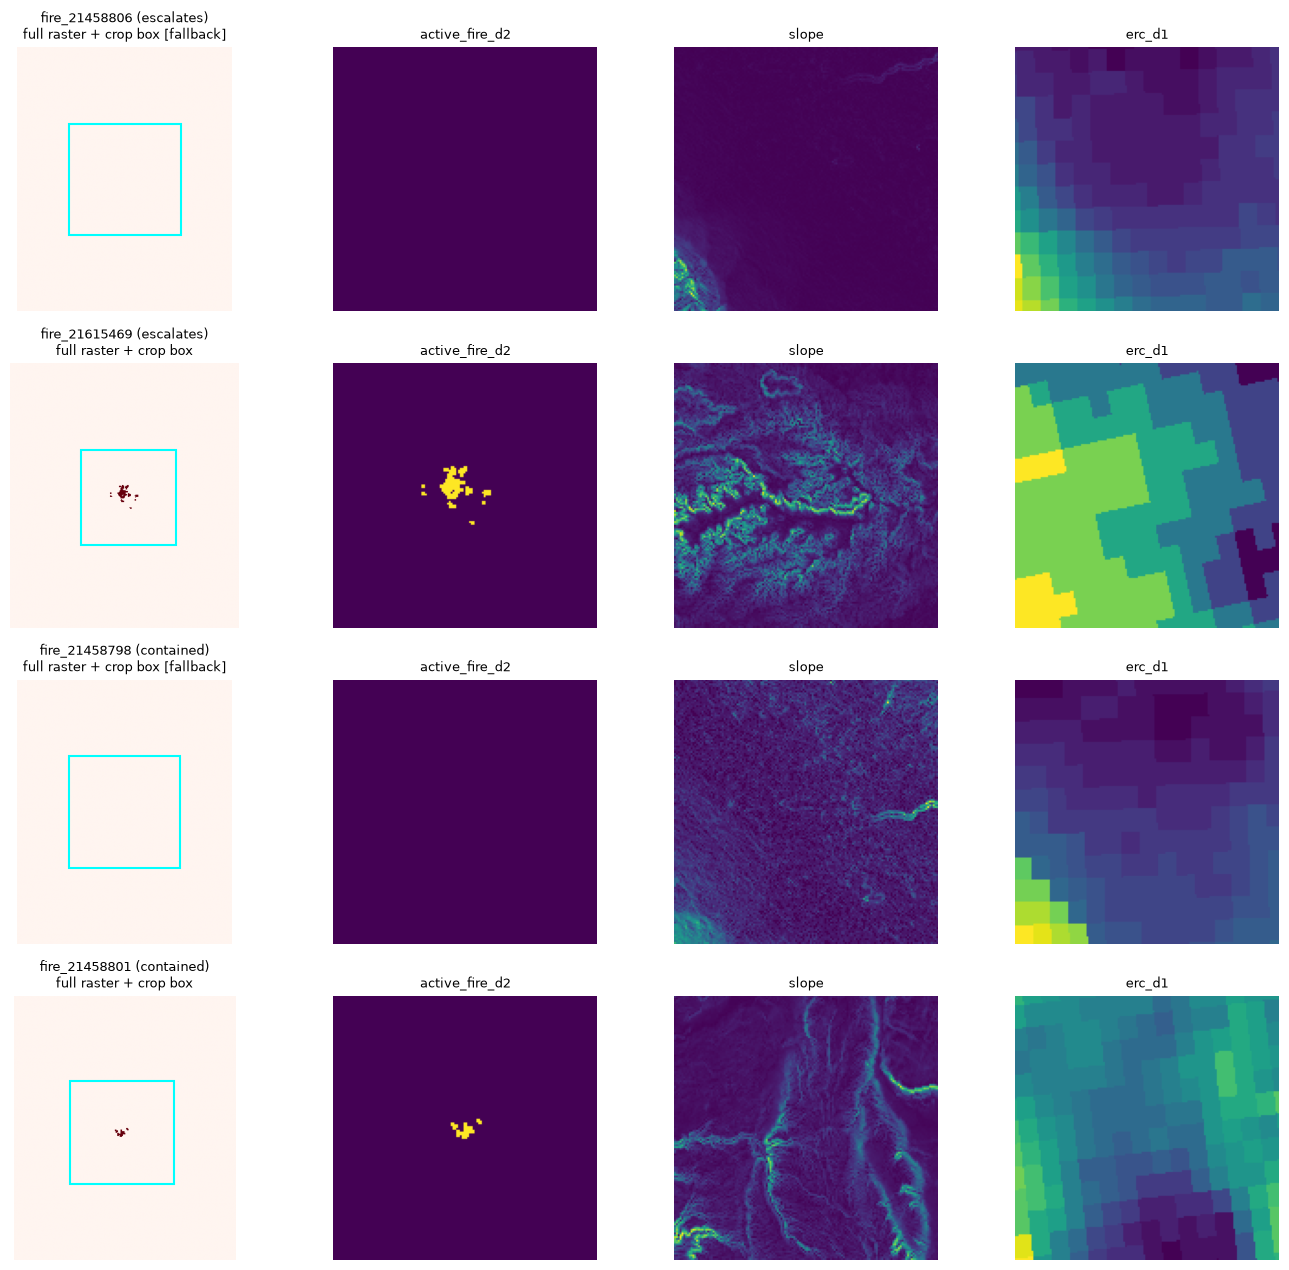

In [5]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt

from flashpoint.data_access import HDF5Event, read_event_window
from flashpoint.rasters import build_plane_stack, early_fire_center, extract_crop

sample_ids = (
    df.loc[df["escalates"] == 1, "event_id"].iloc[:2].tolist()
    + df.loc[df["escalates"] == 0, "event_id"].iloc[:2].tolist()
)

fig, axes = plt.subplots(len(sample_ids), 4, figsize=(14, 3.2 * len(sample_ids)))
for row_i, eid in enumerate(sample_ids):
    r = events_df[events_df["event_id"] == eid].iloc[0]
    event = HDF5Event(
        event_id=eid, year=int(r["year"]), hdf5_path=Path(r["hdf5_path"]),
        n_days=int(r["n_days"]), img_dates=[], lnglat=(r["centroid_lon"], r["centroid_lat"]),
    )
    early = read_event_window(event, BUFFER_DAYS, BUFFER_DAYS + CUTOFF_DAY)
    cy, cx, used_fallback = early_fire_center(early)
    planes, names = build_plane_stack(early)

    ax = axes[row_i, 0]
    ax.imshow(planes[names.index("active_fire_d2")], cmap="Reds")
    half = CROP_SIZE // 2
    rect = patches.Rectangle(
        (cx - half, cy - half), CROP_SIZE, CROP_SIZE,
        fill=False, edgecolor="cyan", linewidth=1.5,
    )
    ax.add_patch(rect)
    label = "escalates" if df.set_index("event_id").loc[eid, "escalates"] else "contained"
    ax.set_title(f"{eid} ({label})\nfull raster + crop box" + (" [fallback]" if used_fallback else ""), fontsize=9)

    crop, was_clipped = extract_crop(planes, cy, cx, STORE_SIZE)
    for col_i, pname in enumerate(["active_fire_d2", "slope", "erc_d1"]):
        ax2 = axes[row_i, col_i + 1]
        ax2.imshow(crop[names.index(pname)], cmap="viridis")
        ax2.set_title(pname, fontsize=9)

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4: tabular baseline (frozen, read not recomputed)

Per CLAUDE.md, `flashpoint_mps` is deliberately lean and doesn't carry
interpret-core/xgboost, so the binary EBM isn't refit here -- these are
the committed numbers from `02_feature_engineering.ipynb` Step 9 / README
"Plan" (base+topo features, `SHAP_COLS`, LOYO over all 4 years). This is
the comparison target for Step 5.

In [7]:
tabular_summary = pd.DataFrame([
    {"model": "ebm (binary, base+topo)", "mean_accuracy": 0.826, "mean_macro_f1": 0.754, "escalates_recall": 0.953},
    {"model": "majority (binary)", "mean_accuracy": 0.73, "mean_macro_f1": 0.42, "escalates_recall": 1.00},
])
print(tabular_summary.to_string(index=False))

# pooled out-of-fold confusion matrix, EBM (binary), from README "Plan":
# rows = true [contained, escalates], cols = predicted [contained, escalates]
EBM_CONFUSION = np.array([[77, 78], [18, 434]])
EBM_FP = int(EBM_CONFUSION[0, 1])
print(f"\nEBM pooled confusion matrix (all {EBM_CONFUSION.sum()} events):")
print(EBM_CONFUSION)
print(f"EBM false positives: {EBM_FP} (of {EBM_CONFUSION[0].sum()} truly contained events)")

                  model  mean_accuracy  mean_macro_f1  escalates_recall
ebm (binary, base+topo)          0.826          0.754             0.953
      majority (binary)          0.730          0.420             1.000

EBM pooled confusion matrix (all 607 events):
[[ 77  78]
 [ 18 434]]
EBM false positives: 78 (of 155 truly contained events)


## Step 5: CNN LOYO x 3 seeds

Default 20-of-26 planes (forecast excluded -- Phase A null result for the
EBM, the CNN's comparison target). Per-fold mean +/- std across seeds,
pooled out-of-fold confusion matrix per seed, and the explicit false-alarm
comparison against the EBM's 78 FPs that motivates this whole arm.

In [8]:
import time

from flashpoint.cnn import get_device, leave_one_year_out_raster
from flashpoint.rasters import default_plane_names

channels = default_plane_names(plane_names)
print(f"device: {get_device()}")
print(f"training on {len(channels)}/{len(plane_names)} planes (forecast excluded): {channels}")

t0 = time.time()
cnn_metrics, cnn_preds = leave_one_year_out_raster(
    crops, plane_names, event_ids, years, labels,
    channels=channels, seeds=SEEDS, crop_size=CROP_SIZE, jitter_px=JITTER_PX,
    return_predictions=True,
)
print(f"\nelapsed: {time.time() - t0:.0f}s")
print(cnn_metrics.to_string(index=False))

device: mps
training on 20/26 planes (forecast excluded): ['slope', 'elevation', 'aspect_sin', 'aspect_cos', 'ndvi', 'pdsi', 'erc_d1', 'erc_d2', 'max_temp_d1', 'max_temp_d2', 'wind_speed_d1', 'wind_speed_d2', 'humidity_d1', 'humidity_d2', 'wind_dir_sin_d1', 'wind_dir_cos_d1', 'wind_dir_sin_d2', 'wind_dir_cos_d2', 'active_fire_d1', 'active_fire_d2']

elapsed: 207s
 test_year  n_test  seed  accuracy  macro_f1  positive_recall
      2018     176     0  0.664773  0.643492         0.610687
      2019      74     0  0.527027  0.519926         0.545455
      2020     201     0  0.781095  0.689902         0.892617
      2021     156     0  0.852564  0.746162         0.914062
      2018     176     1  0.738636  0.711475         0.702290
      2019      74     1  0.675676  0.666917         0.704545
      2020     201     1  0.756219  0.695087         0.812081
      2021     156     1  0.775641  0.712737         0.757812
      2018     176     2  0.767045  0.735241         0.748092
      2019    

In [9]:
per_fold = cnn_metrics.groupby("test_year")[["accuracy", "macro_f1", "positive_recall"]].agg(["mean", "std"])
print("per-fold, across seeds:")
print(per_fold)

overall = cnn_metrics[["accuracy", "macro_f1", "positive_recall"]].agg(["mean", "std"])
print("\noverall (all folds x seeds):")
print(overall)

per-fold, across seeds:
           accuracy            macro_f1           positive_recall          
               mean       std      mean       std            mean       std
test_year                                                                  
2018       0.723485  0.052793  0.696736  0.047617        0.687023  0.069963
2019       0.572072  0.089977  0.566310  0.087216        0.545455  0.159091
2020       0.766169  0.013163  0.682233  0.017961        0.861298  0.043148
2021       0.826923  0.044412  0.743392  0.029367        0.851562  0.082680

overall (all folds x seeds):
      accuracy  macro_f1  positive_recall
mean  0.722162  0.672168         0.736334
std   0.109701  0.081502         0.159854


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(f"===== EBM reference: FP={EBM_FP} =====\n")

fp_by_seed = {}
for seed in SEEDS:
    sp = cnn_preds[cnn_preds["seed"] == seed]
    cm = confusion_matrix(sp["y_true"], sp["y_pred"])
    fp = int(cm[0, 1])
    fp_by_seed[seed] = fp
    print(f"===== seed {seed}: pooled out-of-fold confusion (n={len(sp)}) =====")
    print(cm)
    print(f"FP={fp}  (EBM: {EBM_FP}, delta {fp - EBM_FP:+d})")
    print(classification_report(
        sp["y_true"], sp["y_pred"], target_names=["contained", "escalates"], digits=3,
    ))

print("===== false-positive summary vs. EBM =====")
for seed, fp in fp_by_seed.items():
    print(f"  seed {seed}: FP={fp:>3}  ({fp - EBM_FP:+d} vs. EBM)")
print(f"  mean:    FP={np.mean(list(fp_by_seed.values())):.1f}")

===== EBM reference: FP=78 =====

===== seed 0: pooled out-of-fold confusion (n=607) =====
[[ 92  63]
 [ 98 354]]
FP=63  (EBM: 78, delta -15)
              precision    recall  f1-score   support

   contained      0.484     0.594     0.533       155
   escalates      0.849     0.783     0.815       452

    accuracy                          0.735       607
   macro avg      0.667     0.688     0.674       607
weighted avg      0.756     0.735     0.743       607

===== seed 1: pooled out-of-fold confusion (n=607) =====
[[112  43]
 [111 341]]
FP=43  (EBM: 78, delta -35)
              precision    recall  f1-score   support

   contained      0.502     0.723     0.593       155
   escalates      0.888     0.754     0.816       452

    accuracy                          0.746       607
   macro avg      0.695     0.739     0.704       607
weighted avg      0.790     0.746     0.759       607

===== seed 2: pooled out-of-fold confusion (n=607) =====
[[100  55]
 [ 93 359]]
FP=55  (EBM: 78,

## Step 5b: threshold sweep -- the fair, recall-matched comparison

The FP counts above (43-63 vs. the EBM's 78) all come from the *default*
0.5 threshold on `pos_weight`-adjusted logits -- an operating point
`pos_weight` (n_contained/n_escalates) happened to produce, not something
chosen to match the EBM. The CNN's escalates-recall at that point
(0.74-0.79 pooled, see Step 5's classification reports) is well below the
EBM's 0.953, so the lower FP count may just reflect a laxer recall bar,
not a better model. `cnn_preds["p_escalate"]` already holds the raw
sigmoid probabilities (`leave_one_year_out_raster` stores them regardless
of the decision threshold), so this reruns nothing -- it's a pure
post-hoc sweep over the Step 5 predictions.

In [11]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

assert "p_escalate" in cnn_preds.columns, "cnn_preds has no probabilities -- rerun Step 5"

thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

sweep_rows = []
for seed in SEEDS:
    sp = cnn_preds[cnn_preds["seed"] == seed]
    y_true = sp["y_true"].to_numpy()
    p = sp["p_escalate"].to_numpy()
    for t in thresholds:
        pred = (p >= t).astype(int)
        cm = confusion_matrix(y_true, pred, labels=[0, 1])
        sweep_rows.append({
            "seed": seed,
            "threshold": float(t),
            "accuracy": accuracy_score(y_true, pred),
            "macro_f1": f1_score(y_true, pred, average="macro"),
            "escalates_recall": recall_score(y_true, pred, labels=[1], average=None)[0],
            "fp": int(cm[0, 1]),
        })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

 seed  threshold  accuracy  macro_f1  escalates_recall  fp
    0       0.10  0.782537  0.591671          0.984513 125
    0       0.15  0.799012  0.656470          0.969027 108
    0       0.20  0.799012  0.677071          0.949115  99
    0       0.25  0.795717  0.683918          0.933628  94
    0       0.30  0.789127  0.691888          0.907080  86
    0       0.35  0.777595  0.690499          0.878319  80
    0       0.40  0.767710  0.689939          0.851770  74
    0       0.45  0.757825  0.688721          0.825221  68
    0       0.50  0.734761  0.674031          0.783186  63
    0       0.55  0.714992  0.662180          0.745575  58
    0       0.60  0.705107  0.659571          0.719027  52
    0       0.65  0.688633  0.650713          0.683628  46
    0       0.70  0.655684  0.626378          0.628319  41
    0       0.75  0.616145  0.598860          0.553097  31
    0       0.80  0.532125  0.528531          0.415929  20
    0       0.85  0.431631  0.430239          0.256637  

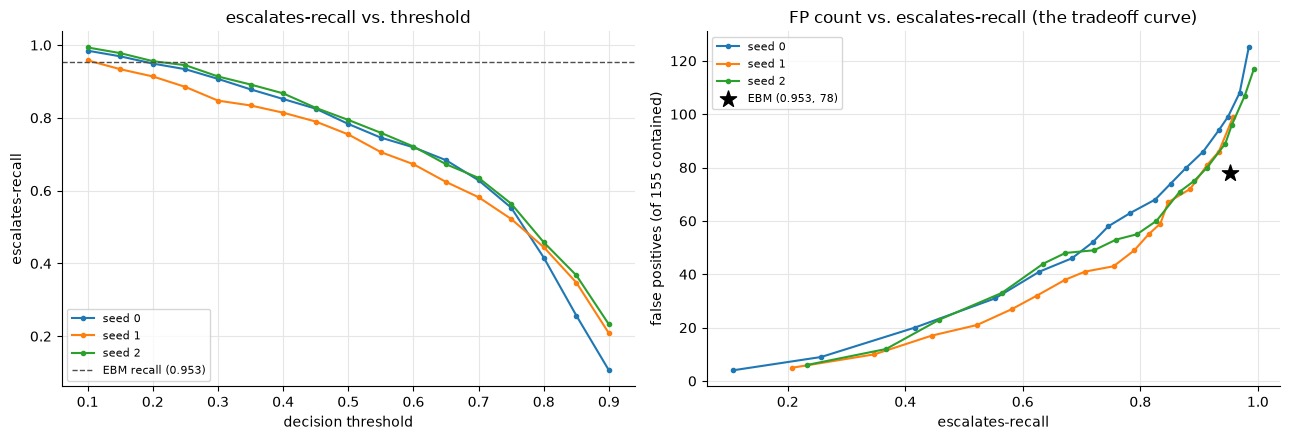

In [12]:
EBM_RECALL = float(tabular_summary.loc[
    tabular_summary["model"] == "ebm (binary, base+topo)", "escalates_recall"
].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for seed in SEEDS:
    s = sweep_df[sweep_df["seed"] == seed]
    ax.plot(s["threshold"], s["escalates_recall"], marker="o", ms=3, label=f"seed {seed}")
ax.axhline(EBM_RECALL, color="0.3", linestyle="--", linewidth=1, label=f"EBM recall ({EBM_RECALL:.3f})")
ax.set_xlabel("decision threshold")
ax.set_ylabel("escalates-recall")
ax.set_title("escalates-recall vs. threshold")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color="0.9")
ax.set_axisbelow(True)

ax = axes[1]
for seed in SEEDS:
    s = sweep_df[sweep_df["seed"] == seed].sort_values("escalates_recall")
    ax.plot(s["escalates_recall"], s["fp"], marker="o", ms=3, label=f"seed {seed}")
ax.scatter([EBM_RECALL], [EBM_FP], color="black", marker="*", s=150, zorder=5, label="EBM (0.953, 78)")
ax.set_xlabel("escalates-recall")
ax.set_ylabel("false positives (of 155 contained)")
ax.set_title("FP count vs. escalates-recall (the tradeoff curve)")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color="0.9")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [13]:
# Fine-grained (0.01-step) search per seed for the threshold whose pooled
# escalates-recall is closest to the EBM's -- the coarse 0.05 grid above is
# for the overview plot, this is for the one number that matters.
fine_thresholds = np.arange(0.01, 1.00, 0.01)

matched_rows = []
for seed in SEEDS:
    sp = cnn_preds[cnn_preds["seed"] == seed]
    y_true = sp["y_true"].to_numpy()
    p = sp["p_escalate"].to_numpy()

    best = None
    for t in fine_thresholds:
        pred = (p >= t).astype(int)
        rec = recall_score(y_true, pred, labels=[1], average=None)[0]
        diff = abs(rec - EBM_RECALL)
        if best is None or diff < best[0]:
            cm = confusion_matrix(y_true, pred, labels=[0, 1])
            best = (diff, float(t), rec, int(cm[0, 1]))

    _, matched_t, matched_recall, matched_fp = best
    matched_rows.append({
        "seed": seed, "matched_threshold": matched_t,
        "cnn_recall": matched_recall, "cnn_fp": matched_fp,
    })

matched_df = pd.DataFrame(matched_rows)
print(matched_df.to_string(index=False))

print(f"\n===== apples-to-apples: FP count at EBM-matched escalates-recall ({EBM_RECALL:.3f}) =====")
print(f"EBM:  recall={EBM_RECALL:.3f}  FP={EBM_FP}")
for row in matched_rows:
    delta = row["cnn_fp"] - EBM_FP
    print(f"CNN seed {row['seed']}: threshold={row['matched_threshold']:.2f}  "
          f"recall={row['cnn_recall']:.3f}  FP={row['cnn_fp']:>3}  ({delta:+d} vs. EBM)")

mean_matched_fp = np.mean([r["cnn_fp"] for r in matched_rows])
print(f"\nmean CNN FP at matched recall: {mean_matched_fp:.1f}  (EBM: {EBM_FP})")

if mean_matched_fp < EBM_FP:
    print(
        "\nVerdict: at EBM-matched escalates-recall, the CNN still produces fewer false "
        "alarms -- this is a genuine improvement, not an artifact of a laxer recall bar."
    )
elif mean_matched_fp > EBM_FP:
    print(
        "\nVerdict: at EBM-matched escalates-recall, the CNN produces MORE false alarms "
        "than the EBM, not fewer. The default-threshold FP win in Step 5 (43-63 vs. 78) "
        "was an artifact of accepting lower recall (0.74-0.79 vs. 0.953), not a better "
        "underlying tradeoff -- the two models sit on similar points of a similar "
        "precision-recall curve once compared at the same recall level."
    )
else:
    print("\nVerdict: at EBM-matched escalates-recall, the CNN and EBM land on effectively the same FP count.")

 seed  matched_threshold  cnn_recall  cnn_fp
    0               0.19     0.95354     100
    1               0.11     0.95354      96
    2               0.21     0.95354      93

===== apples-to-apples: FP count at EBM-matched escalates-recall (0.953) =====
EBM:  recall=0.953  FP=78
CNN seed 0: threshold=0.19  recall=0.954  FP=100  (+22 vs. EBM)
CNN seed 1: threshold=0.11  recall=0.954  FP= 96  (+18 vs. EBM)
CNN seed 2: threshold=0.21  recall=0.954  FP= 93  (+15 vs. EBM)

mean CNN FP at matched recall: 96.3  (EBM: 78)

Verdict: at EBM-matched escalates-recall, the CNN produces MORE false alarms than the EBM, not fewer. The default-threshold FP win in Step 5 (43-63 vs. 78) was an artifact of accepting lower recall (0.74-0.79 vs. 0.953), not a better underlying tradeoff -- the two models sit on similar points of a similar precision-recall curve once compared at the same recall level.


## Retrieving trained fold models (needed for Grad-CAM)

Step 5's LOYO loop discarded each fold's model after scoring it -- only
metrics and (since Step 5b) predicted probabilities were kept. Grad-CAM
needs the actual weights, and specifically the *out-of-fold* model for
each exemplar event (the fold that held out that event's year), so this
reruns `leave_one_year_out_raster` once more with `return_models=True`,
same config as Step 5 (same seeds, same channels). This is a fresh
training pass, not a cache hit -- expect it to take about as long as Step
5 did (~3.5 min). Training isn't bit-deterministic on MPS, so the
resulting predictions won't match Step 5's exactly; the sanity check below
compares them to make sure they're close, not identical.

Models come back on CPU (Grad-CAM over a handful of exemplars, or even all
607 events for Step 8, is cheap for a ~100k-param model -- no need to keep
fighting MPS for this part).

In [17]:
t0 = time.time()
cnn_metrics2, cnn_preds2, cnn_models = leave_one_year_out_raster(
    crops, plane_names, event_ids, years, labels,
    channels=channels, seeds=SEEDS, crop_size=CROP_SIZE, jitter_px=JITTER_PX,
    return_predictions=True, return_models=True,
)
print(f"elapsed: {time.time() - t0:.0f}s")
print(f"{len(cnn_models)} fold models retained: {sorted(cnn_models.keys())}")

# sanity check vs. Step 5's original run -- same config/seeds, so this should
# be close (not necessarily bit-identical -- MPS training isn't guaranteed
# deterministic run to run).
merged = cnn_preds.merge(
    cnn_preds2, on=["event_id", "seed"], suffixes=("_orig", "_v2"),
)
agree = (merged["y_pred_orig"] == merged["y_pred_v2"]).mean()
acc_delta = cnn_metrics2["accuracy"].mean() - cnn_metrics["accuracy"].mean()
print(f"\nhard-label agreement with Step 5's run: {agree:.1%}")
print(f"mean accuracy delta (v2 - original): {acc_delta:+.3f}")

elapsed: 185s
12 fold models retained: [(np.int32(2018), 0), (np.int32(2018), 1), (np.int32(2018), 2), (np.int32(2019), 0), (np.int32(2019), 1), (np.int32(2019), 2), (np.int32(2020), 0), (np.int32(2020), 1), (np.int32(2020), 2), (np.int32(2021), 0), (np.int32(2021), 1), (np.int32(2021), 2)]

hard-label agreement with Step 5's run: 87.7%
mean accuracy delta (v2 - original): +0.004


## Step 7: Grad-CAM exemplars

Two exemplar sets, same TP/TN/FP/FN framing as `02_feature_engineering.ipynb`
Step 10:

- **(a) The EBM's own exemplars** -- the exact four `event_id`s from
  notebook 02 Step 10's printed output (`fire_24461347` TP, `fire_24695758`
  TN, `fire_24462912` FP, `fire_23300699` FN), run through the CNN's
  out-of-fold model for that event's year. "Same events, two lenses":
  does the CNN's attention on the EBM's own false-alarm exemplar
  (`fire_24462912`, hot/dry early conditions on a fire that then stopped)
  look any different from its attention on a true negative?
- **(b) The CNN's own out-of-fold exemplars** -- the most confident
  correct/incorrect event in each confusion-matrix cell, pooled across all
  3 seeds' out-of-fold predictions (mirrors notebook 02's `pick_exemplar`).

Grad-CAM overlays are shown on the day-2 active-fire plane, same
crop-and-overlay visual style as Step 3.

In [18]:
from flashpoint.cnn import EarlyCropDataset, grad_cam, select_channels

sub = select_channels(crops, plane_names, channels)  # (607, 20, STORE_SIZE, STORE_SIZE)
event_id_to_idx = {eid: i for i, eid in enumerate(event_ids)}
CENTER_OFF = (STORE_SIZE - CROP_SIZE) // 2  # eval crops are center-crops, no jitter


def raw_center_crop(idx: int) -> np.ndarray:
    """Un-normalized, center-cropped (C, CROP_SIZE, CROP_SIZE) planes for one event."""
    return sub[idx, :, CENTER_OFF:CENTER_OFF + CROP_SIZE, CENTER_OFF:CENTER_OFF + CROP_SIZE]


def cam_input(idx: int, fold_key: tuple) -> torch.Tensor:
    """Normalized (1, C, CROP_SIZE, CROP_SIZE) tensor for one event under one fold's stats."""
    fold = cnn_models[fold_key]
    ds = EarlyCropDataset(
        sub[[idx]], labels[[idx]], fold["mean"], fold["std"],
        crop_size=CROP_SIZE, jitter_px=JITTER_PX, train=False,
    )
    x, _ = ds[0]
    return x.unsqueeze(0)


# (a) the EBM's own exemplars, from 02_feature_engineering.ipynb Step 10's
# printed output -- hardcoded event_ids, not re-derived (that notebook isn't
# run from here).
EBM_EXEMPLAR_IDS = {
    "TRUE POSITIVE": "fire_24461347",
    "TRUE NEGATIVE": "fire_24695758",
    "FALSE POSITIVE": "fire_24462912",
    "FALSE NEGATIVE": "fire_23300699",
}
EBM_EXEMPLAR_SEED = 0  # arbitrary, illustrative only -- any seed's fold model works

ebm_exemplars = []
for label, eid in EBM_EXEMPLAR_IDS.items():
    idx = event_id_to_idx[eid]
    test_year = int(years[idx])
    row = cnn_preds2[(cnn_preds2["event_id"] == eid) & (cnn_preds2["seed"] == EBM_EXEMPLAR_SEED)]
    p = float(row["p_escalate"].iloc[0]) if not row.empty else float("nan")
    ebm_exemplars.append((label, eid, test_year, EBM_EXEMPLAR_SEED, p))
    print(f"{label:<16} {eid} ({test_year}) CNN P(escalate)={p:.3f}")

print()


# (b) the CNN's own out-of-fold exemplars, pooled across all 3 seeds --
# most confident event in each confusion-matrix cell (mirrors notebook 02's
# pick_exemplar).
def pick_cnn_exemplar(y_true, y_pred, highest_p):
    cell = cnn_preds2[(cnn_preds2["y_true"] == y_true) & (cnn_preds2["y_pred"] == y_pred)]
    if cell.empty:
        return None
    idx = cell["p_escalate"].idxmax() if highest_p else cell["p_escalate"].idxmin()
    return cell.loc[idx]


cnn_exemplar_specs = {
    "TRUE POSITIVE": (1, 1, True),
    "TRUE NEGATIVE": (0, 0, False),
    "FALSE POSITIVE": (0, 1, True),
    "FALSE NEGATIVE": (1, 0, False),
}
cnn_exemplars = []
for label, (yt, yp, highest) in cnn_exemplar_specs.items():
    row = pick_cnn_exemplar(yt, yp, highest)
    if row is None:
        print(f"{label:<16} no such events")
        continue
    cnn_exemplars.append((label, row["event_id"], int(row["test_year"]), int(row["seed"]), float(row["p_escalate"])))
    print(f"{label:<16} {row['event_id']} ({int(row['test_year'])}, seed {int(row['seed'])}) "
          f"P(escalate)={row['p_escalate']:.3f}")

TRUE POSITIVE    fire_24461347 (2020) CNN P(escalate)=0.895
TRUE NEGATIVE    fire_24695758 (2020) CNN P(escalate)=0.064
FALSE POSITIVE   fire_24462912 (2020) CNN P(escalate)=0.883
FALSE NEGATIVE   fire_23300699 (2019) CNN P(escalate)=0.038

TRUE POSITIVE    fire_21890007 (2018, seed 1) P(escalate)=0.973
TRUE NEGATIVE    fire_23757522 (2020, seed 1) P(escalate)=0.029
FALSE POSITIVE   fire_21998157 (2018, seed 1) P(escalate)=0.969
FALSE NEGATIVE   fire_23493973 (2019, seed 0) P(escalate)=0.032


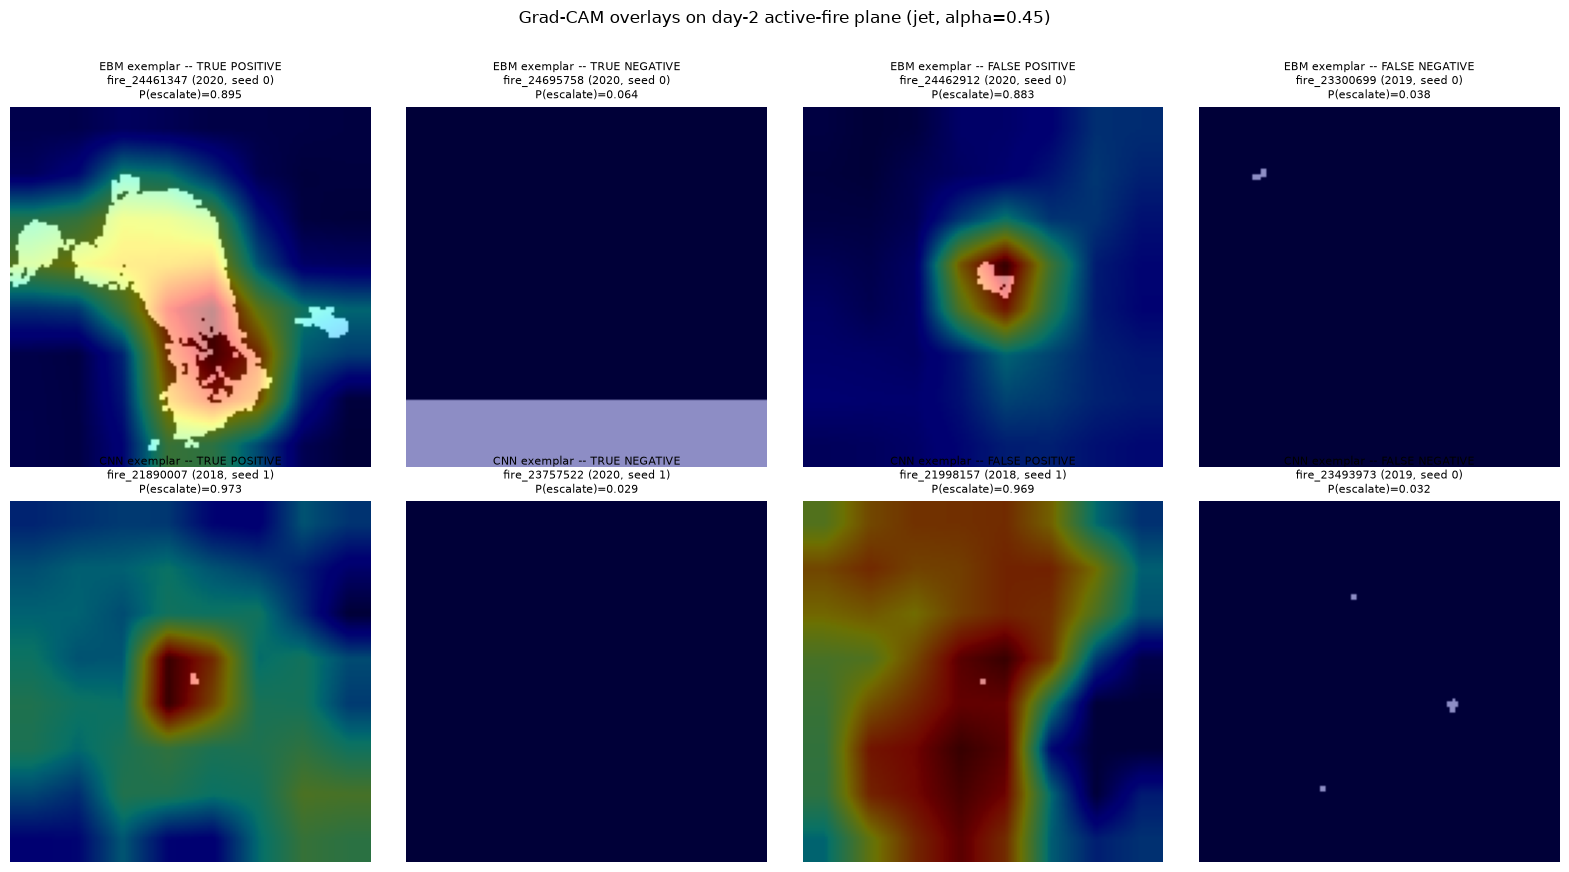

In [19]:
def plot_cam_row(axes_row, exemplar_list, row_title):
    fire_idx = channels.index("active_fire_d2")
    for ax, (label, eid, test_year, seed, p) in zip(axes_row, exemplar_list):
        idx = event_id_to_idx[eid]
        model = cnn_models[(test_year, seed)]["model"]
        x = cam_input(idx, (test_year, seed))
        cam = grad_cam(model, x)[0]

        fire_plane = raw_center_crop(idx)[fire_idx]
        ax.imshow(fire_plane, cmap="gray")
        ax.imshow(cam, cmap="jet", alpha=0.45, vmin=0, vmax=1)
        ax.set_title(f"{row_title}{label}\n{eid} ({test_year}, seed {seed})\nP(escalate)={p:.3f}", fontsize=8)
        ax.axis("off")


fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
plot_cam_row(axes[0], ebm_exemplars, "EBM exemplar -- ")
plot_cam_row(axes[1], cnn_exemplars, "CNN exemplar -- ")
fig.suptitle("Grad-CAM overlays on day-2 active-fire plane (jet, alpha=0.45)", y=1.02)
plt.tight_layout()
plt.show()

## Step 8: quantitative CAM statistics over all 607 events

Framing note, given Step 5b: the threshold sweep showed the CNN and EBM
sit on a similar precision-recall tradeoff curve, not that the CNN found a
genuinely different, better error profile (at EBM-matched escalates-recall
the CNN did not clearly beat the EBM's FP count -- see the Step 5b
verdict). So the question this step answers is **not** "why does the CNN
trade off differently" -- it doesn't, materially. It's narrower and more
modest: **does the CNN attend to physically sensible regions (near the
early fire, on steeper slopes, at higher ERC) despite performance that is
comparable to, not better than, the tabular baseline?** That's still worth
knowing for the interpretability comparison even if the CNN isn't a
performance win.

Two statistics per event, computed from each event's out-of-fold Grad-CAM
(one per seed, using that seed's fold model -- 3 x 607 CAMs total):

- **(a) CAM mass fraction within 5px (~1.9km) of early fire pixels**, vs.
  the uniform-expectation baseline (what fraction of the 128x128 crop's
  pixels are within 5px of fire, i.e. what a spatially-uninformed CAM
  would give by chance). Events with zero fire pixels in the eval crop
  (~26%, the same fallback-center events from Step 2) are excluded --
  "distance to fire" is undefined for them.
- **(b) Per-event Spearman correlation of the CAM against the slope plane,
  and against the erc plane.**

The comparison against EBM term importances (fire_extent 0.445, slope
0.277, erc 0.205) below is **qualitative, not a joint statistical test**
-- those are mean-|logit-contribution| importances in a completely
different space from a spatial CAM-mass uplift ratio or a Spearman
correlation. Agreement in *direction* (CNN attends more than chance near
fire; CAM correlates positively with slope/erc) is a mild, sensible
finding; it is not evidence the CNN "learned the same thing" as the EBM,
and the numbers below shouldn't be read that way.

In [20]:
from scipy import ndimage
from scipy.stats import spearmanr

fire_idx_d1 = channels.index("active_fire_d1")
fire_idx_d2 = channels.index("active_fire_d2")
slope_idx = channels.index("slope")
erc_idx = channels.index("erc_d1")
NEAR_PX = 5

t0 = time.time()
stat_rows = []
for seed in SEEDS:
    for i, eid in enumerate(event_ids):
        test_year = int(years[i])
        fold = cnn_models[(test_year, seed)]
        model = fold["model"]

        x = cam_input(i, (test_year, seed))
        cam = grad_cam(model, x)[0]  # (CROP_SIZE, CROP_SIZE), normalized to [0, 1]

        raw = raw_center_crop(i)
        fire_mask = (raw[fire_idx_d1] > 0) | (raw[fire_idx_d2] > 0)
        n_fire_px = int(fire_mask.sum())
        slope_plane = raw[slope_idx]
        erc_plane = raw[erc_idx]

        row = {"event_id": eid, "seed": seed, "test_year": test_year, "n_fire_px": n_fire_px}

        if n_fire_px > 0:
            dist = ndimage.distance_transform_edt(~fire_mask)
            near_mask = dist <= NEAR_PX
            cam_sum = float(cam.sum())
            row["near_fire_pixel_frac"] = float(near_mask.mean())
            row["near_fire_cam_frac"] = float(cam[near_mask].sum() / cam_sum) if cam_sum > 0 else np.nan
        else:
            row["near_fire_pixel_frac"] = np.nan
            row["near_fire_cam_frac"] = np.nan

        cam_flat = cam.ravel()
        row["spearman_cam_slope"] = (
            spearmanr(cam_flat, slope_plane.ravel())[0] if np.std(cam_flat) > 0 and np.std(slope_plane) > 0 else np.nan
        )
        row["spearman_cam_erc"] = (
            spearmanr(cam_flat, erc_plane.ravel())[0] if np.std(cam_flat) > 0 and np.std(erc_plane) > 0 else np.nan
        )
        stat_rows.append(row)

cam_stats_df = pd.DataFrame(stat_rows)
print(f"elapsed: {time.time() - t0:.0f}s, {len(cam_stats_df)} event x seed rows")
print(cam_stats_df.head().to_string(index=False))

elapsed: 35s, 1821 event x seed rows
     event_id  seed  test_year  n_fire_px  near_fire_pixel_frac  near_fire_cam_frac  spearman_cam_slope  spearman_cam_erc
fire_21458798     0       2018          0                   NaN                 NaN                 NaN               NaN
fire_21458801     0       2018         76              0.023865                 NaN                 NaN               NaN
fire_21458806     0       2018          0                   NaN                 NaN                 NaN               NaN
fire_21458836     0       2018          0                   NaN                 NaN                 NaN               NaN
fire_21458848     0       2018         64              0.029175                 NaN                 NaN               NaN


In [21]:
valid = cam_stats_df.dropna(subset=["near_fire_cam_frac"])
n_excluded_events = cam_stats_df.loc[cam_stats_df["n_fire_px"] == 0, "event_id"].nunique()
print(f"events with zero fire pixels in the eval crop (excluded from (a)): {n_excluded_events}/607")
print(f"({len(valid)} of {len(cam_stats_df)} event x seed rows retained for (a))")

mean_cam_near = valid["near_fire_cam_frac"].mean()
mean_pixel_near = valid["near_fire_pixel_frac"].mean()
uplift = mean_cam_near / mean_pixel_near if mean_pixel_near > 0 else np.nan

mean_rho_slope = cam_stats_df["spearman_cam_slope"].mean()
mean_rho_erc = cam_stats_df["spearman_cam_erc"].mean()
frac_pos_slope = (cam_stats_df["spearman_cam_slope"] > 0).mean()
frac_pos_erc = (cam_stats_df["spearman_cam_erc"] > 0).mean()

print(f"\n(a) mean CAM mass fraction within {NEAR_PX}px of fire: {mean_cam_near:.3f}")
print(f"    uniform-expectation baseline (pixel fraction within {NEAR_PX}px): {mean_pixel_near:.3f}")
print(f"    uplift ratio: {uplift:.2f}x")

print(f"\n(b) mean per-event Spearman(CAM, slope): {mean_rho_slope:+.3f}  ({frac_pos_slope:.1%} of events positive)")
print(f"    mean per-event Spearman(CAM, erc):   {mean_rho_erc:+.3f}  ({frac_pos_erc:.1%} of events positive)")

ebm_importance = pd.Series({"fire_extent": 0.445, "slope": 0.277, "erc": 0.205}, name="EBM mean |logit contribution|")
cam_proxy = pd.Series({
    "fire_extent (near-fire CAM uplift, x)": uplift,
    "slope (mean Spearman rho)": mean_rho_slope,
    "erc (mean Spearman rho)": mean_rho_erc,
}, name="CNN CAM proxy (different units -- not comparable in scale)")

print("\n===== EBM term importances =====")
print(ebm_importance.to_string())
print("\n===== CNN CAM proxy statistics =====")
print(cam_proxy.to_string())

events with zero fire pixels in the eval crop (excluded from (a)): 161/607
(1265 of 1821 event x seed rows retained for (a))

(a) mean CAM mass fraction within 5px of fire: 0.158
    uniform-expectation baseline (pixel fraction within 5px): 0.040
    uplift ratio: 3.97x

(b) mean per-event Spearman(CAM, slope): +0.238  (67.4% of events positive)
    mean per-event Spearman(CAM, erc):   +0.203  (56.7% of events positive)

===== EBM term importances =====
fire_extent    0.445
slope          0.277
erc            0.205

===== CNN CAM proxy statistics =====
fire_extent (near-fire CAM uplift, x)    3.965477
slope (mean Spearman rho)                0.238075
erc (mean Spearman rho)                  0.202869


In [22]:
print("===== plain-language read (computed from the numbers above, not asserted in advance) =====\n")

if uplift > 1.1:
    print(f"- Near-fire attention: CAM mass is concentrated near early fire pixels "
          f"({uplift:.2f}x the uniform baseline) -- the CNN attends to the fire's own "
          f"footprint more than a spatially-blind model would, which is the physically "
          f"sensible thing to do given fire_extent is the EBM's top feature.")
elif uplift < 0.9:
    print(f"- Near-fire attention: CAM mass is actually LOWER near early fire pixels than "
          f"the uniform baseline would predict ({uplift:.2f}x) -- the CNN is not "
          f"concentrating on the fire's own footprint, which does not match the EBM's "
          f"fire_extent-dominated importance ranking.")
else:
    print(f"- Near-fire attention: CAM mass near fire is roughly what a spatially-uninformed "
          f"model would give by chance ({uplift:.2f}x) -- no clear evidence of fire-seeking "
          f"attention.")

for name, rho, frac_pos in [("slope", mean_rho_slope, frac_pos_slope), ("erc", mean_rho_erc, frac_pos_erc)]:
    if rho > 0.05:
        print(f"- {name.capitalize()}: mean per-event CAM-{name} correlation is positive "
              f"({rho:+.3f}, positive in {frac_pos:.0%} of events) -- directionally consistent "
              f"with the EBM's positive {name} importance, but this is a weak/qualitative "
              f"resemblance, not a matched-magnitude finding.")
    elif rho < -0.05:
        print(f"- {name.capitalize()}: mean per-event CAM-{name} correlation is NEGATIVE "
              f"({rho:+.3f}) -- this does not match the EBM's positive {name} importance; "
              f"the CNN is not obviously attending to {name} the way the EBM weights it.")
    else:
        print(f"- {name.capitalize()}: mean per-event CAM-{name} correlation is close to zero "
              f"({rho:+.3f}) -- no clear spatial relationship between CAM attention and {name}.")

print(
    "\nOverall: given Step 5b's finding that the CNN and EBM sit on a similar precision-recall "
    "tradeoff rather than a genuinely different error profile, these CAM statistics are read as "
    "a check on whether the CNN's attention is at least physically plausible despite comparable "
    "performance -- not as evidence it discovered a better or different signal than the tabular "
    "model. Any agreement in direction above is exactly that: directional agreement, not proof "
    "the two models learned the same thing."
)

===== plain-language read (computed from the numbers above, not asserted in advance) =====

- Near-fire attention: CAM mass is concentrated near early fire pixels (3.97x the uniform baseline) -- the CNN attends to the fire's own footprint more than a spatially-blind model would, which is the physically sensible thing to do given fire_extent is the EBM's top feature.
- Slope: mean per-event CAM-slope correlation is positive (+0.238, positive in 67% of events) -- directionally consistent with the EBM's positive slope importance, but this is a weak/qualitative resemblance, not a matched-magnitude finding.
- Erc: mean per-event CAM-erc correlation is positive (+0.203, positive in 57% of events) -- directionally consistent with the EBM's positive erc importance, but this is a weak/qualitative resemblance, not a matched-magnitude finding.

Overall: given Step 5b's finding that the CNN and EBM sit on a similar precision-recall tradeoff rather than a genuinely different error profile, these CA